(Regresjon)= 
### Regresjon
Når vi jobber med reelle datasett ønsker vi ofte å finne ut hvilken matematisk funksjon som passer best til dataene.

Når vi har funnet en matematisk funksjon er mulighetene mange. Vi kan lage en modell som ser hva som har skjedd imellom, før og etter datapunktene våre. Som en slags data-trollmann kan vi altså både spå fremtiden og se tilbake i tid 🧙‍♂️🔮

Her kommer et eksempel på hvordan konsumprisindeksen (KPI) har økt siden 2015.

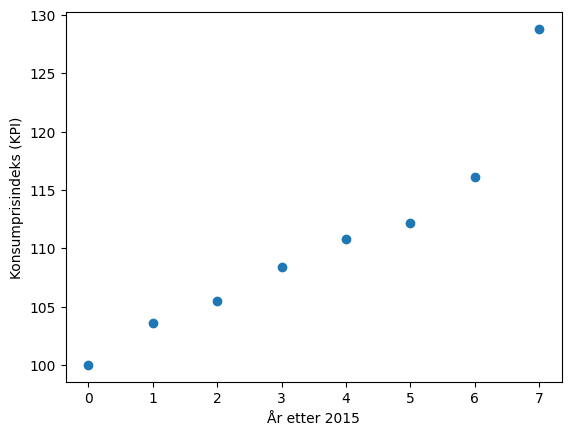

In [46]:
import matplotlib.pyplot as plt

x = [0, 1, 2, 3, 4, 5, 6, 7] # År etter 2015
y = [100, 103.6, 105.5, 108.4, 110.8, 112.2, 116.1, 128.8] # Konsumprisindeks

plt.scatter(x, y)
plt.xlabel("År etter 2015")
plt.ylabel("Konsumprisindeks (KPI)")
plt.show()

Hvilken matematisk funksjon tror du passer best her?

#### Regresjon med polynomer

For å lage en polynomfunksjon som passer til et sett med data kan vi bruke `np.polynomial.Polynomial.fit()`. Denne returnerer et polynom som er tilpasset dataene.

Eksempelvis kan vi skrive `np.polynomial.Polynomial.fit(x, y, deg = 1)` for å få et polynom av grad `1` fra x-verdiene i arrayet `x` og y-verdiene i arrayet `y`. 

##### Linje
En linje er et polynom av grad 1. Vi kan finne den linjen som passer best til dataene på denne måten.

Funksjonsuttrykk: 98.73333333333328 + 3.411904761904767 x**1
KPI i 2023 ifølge modellen: 126


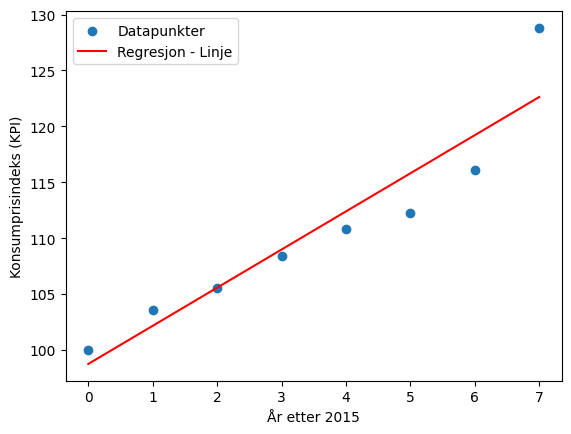

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5, 6, 7]) # År etter 2015
y = np.array([100, 103.6, 105.5, 108.4, 110.8, 112.2, 116.1, 128.8]) # Konsumprisindeks

pol = np.polynomial.Polynomial.fit(x, y, deg = 1)

print("Funksjonsuttrykk:", pol.convert()) # Skriver ut funksjonsuttrykket for linjen

print("KPI i 2023 ifølge modellen:", round(pol(8))) # Skriver ut KPI fra modellen.

plt.scatter(x, y, label = "Datapunkter")
plt.plot(x, pol(x), label = "Regresjon - Linje", color = "red")
plt.xlabel("År etter 2015")
plt.ylabel("Konsumprisindeks (KPI)")
plt.legend()
plt.show()

Vi ser at funksjonsuttrykket blir en typisk linje på formen $ax + b$. 

Når vi skriver `pol(8)` får vi konsumprisindeksen modellen tilsier at det vil bli i 2023.

```{admonition} Skrive ut polynomet
:class: warning
Når vi skal skrive ut polynomet må vi bruke `.convert()`-funksjonen. Hvis ikke får vi feil koeffisienter.
```

##### Andregradsfunksjon (grad 2)

Ved å skrive `deg = 2` som parameter i `np.polynomial.Polynomial.fit()` kan vi få en andregradsfunksjon.

Funksjonsuttrykk: 101.7416666666666 + 0.40357142857143957 x**1 + 0.4297619047619039 x**2
KPI i 2023 ifølge modellen: 132


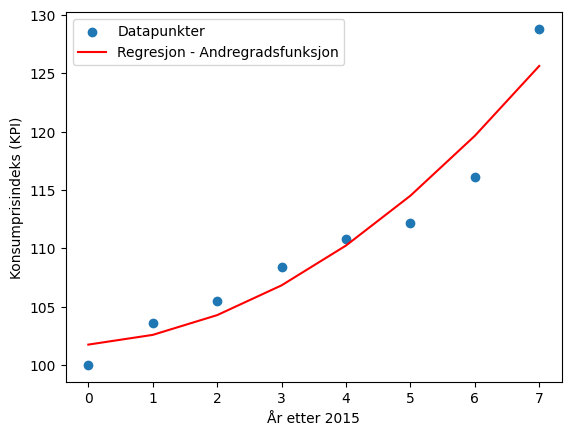

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5, 6, 7]) # År etter 2015
y = np.array([100, 103.6, 105.5, 108.4, 110.8, 112.2, 116.1, 128.8]) # Konsumprisindeks

pol = np.polynomial.Polynomial.fit(x, y, deg = 2)

print("Funksjonsuttrykk:", pol.convert()) # Skriver ut funksjonsuttrykket for linjen
print("KPI i 2023 ifølge modellen:", round(pol(8))) # Skriver ut KPI fra modellen.

plt.scatter(x, y, label = "Datapunkter")
plt.plot(x, pol(x), label = "Regresjon - Andregradsfunksjon", color = "red")
plt.xlabel("År etter 2015")
plt.ylabel("Konsumprisindeks (KPI)")
plt.legend()
plt.show()

Ved å endre `deg`-parameteren til `np.polynomial.Polynomial.fit()` kan vi gjøre regresjon med polynomer av enda høyere grad.

#### Regresjon med generelle funksjonsuttrykk
> Denne delen krever `scipy`-pakken. Mange Python-installasjoner har denne allerede, men man kan også installere den ved å kjøre `pip install scipy` i terminalvinduet.

Hvis vi ønsker å tilpasse en annen type matematisk funksjon enn polynomer kan vi bruke `scipy.optimize.curve_fit()`-funksjonen.

Da må vi spesifisere hvilken form den matematiske funksjonen vil ha.

I dette eksempelet vil jeg tilpasse en logistisk funksjon på formen $f(x)=\frac{B}{1+a\cdot e^{-kx}}$.

Koeffisienter B, a, k: [441.4070449  232.58325342   0.51951266]


C:\Users\tobiasmelb\AppData\Local\Temp\ipykernel_28000\3620722994.py:9: RuntimeWarning: overflow encountered in power
  return B/(1 + a * np.e**(-k * x))


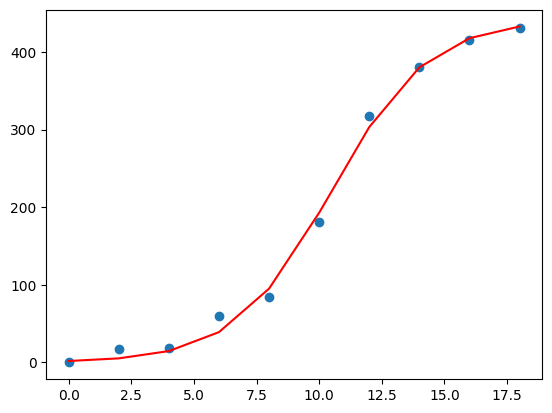

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

x = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18])
y = np.array([0, 17, 19, 60, 84, 181, 317, 380, 415, 431])

def f(x, B, a, k): # Skriver inn variabel og koeffisienter
    return B/(1 + a * np.e**(-k * x))

popt, pcov = curve_fit(f, x, y) # popt er koeffisientene. pcov er kovariansen til koeffisientene

print("Koeffisienter B, a, k:", popt)

plt.scatter(x, y, label = "Datapunkter")
plt.plot(x, f(x, *popt), color="red", label = "Tilpasset potensfunksjon x^a")
plt.show()

Legg merke til funksjonskallet `f(x, *popt)` i nest siste linje. `*popt` er det samme som å sette inn koeffisientene `B, a, k`, fordi `popt` er en array med koefissienter. Dermed settes alle parameterene `x, B, a, k` inn i funksjonen `f(x, B, a, k)`.

---

#### Oppgaver

##### Oppgave 1
Finn SSB Tabell 05803: Endringer i befolkningen i løpet av året etter år og statistikkvariabel. 

1. Velg "Befolkning 1. januar" og "Alle år". 
2. Last ned dataene som fil og kall den "befolkning.csv".
3. Plott datapunktene.
4. Gjør en lineær regresjon og plott det i samme vindu.
5. Gjør en polynomregresjon av grad 3 og plott det i samme vindu.
5. Gjør en regresjon med en funksjon på formen $A^x$ og plott det i samme vindu.

Skriv ut befolkningstallet i 2050 for alle de tre modellene. Hvilken tror du passer best?

##### Oppgave 2

Her ([lenke](https://www.uio.no/studier/emner/matnat/natfag/NAT3000/h21/datafiler/antall-meldte-covid-19.txt)) er en datafil for hvor mange som ble syke med covid i 2020 og 2021

1. Lag en array med kumulativt antall syke.
2. Gjør en regresjonsanalyse med en funksjonstype som du velger selv.
3. Plott datapunktene og regresjonsmodellen i samme plott.
4. Regn ut hvor mange syke det kommer til å være 1. Jan, 2023 ifølge modellen din.